Baseline Macro F1 Score: 0.9932

Top 10 Most Predictive Features:
                     Feature  Importance
19              fCO2_per_SST    0.681034
17  SST_salinity_interaction    0.062903
2                        SST    0.057320
15                   abs_lat    0.037377
0                        lat    0.028891
1                        lon    0.021327
5               ETOPO2_depth    0.019261
14               day_of_year    0.015863
3                    WOA_SSS    0.014376
9             shipping_proxy    0.009490

Contribution of Engineered Features:
               Feature  Importance
9       shipping_proxy    0.009490
11  shipping_intensity    0.008502
12           month_sin    0.006524
13           month_cos    0.005407


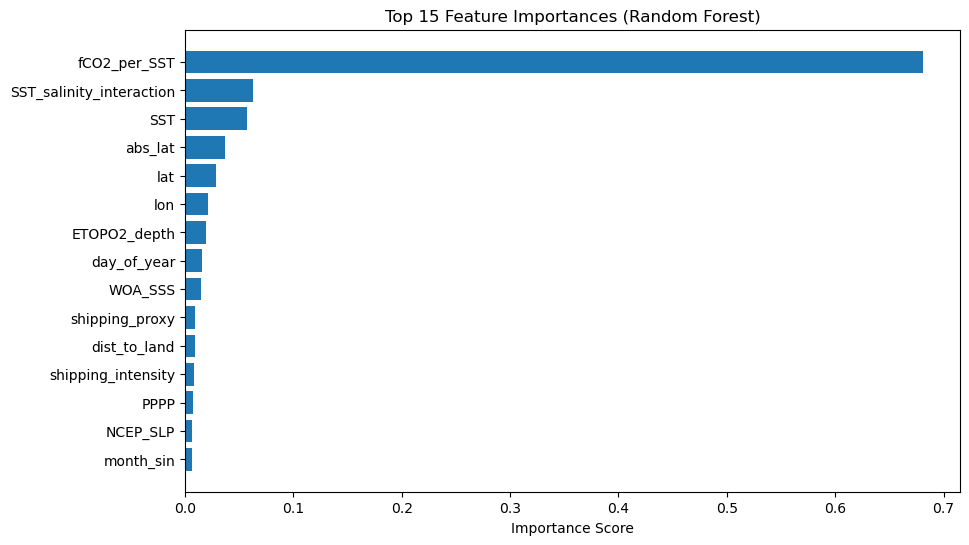

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

# 1. Load the preprocessed data
df = pd.read_csv('ocean_acidity_preprocessed.csv')

# 2. Define features (X) and target (y)
# We drop the categorical label and keep the encoded target
X = df.drop(columns=['acidity_level', 'acidity_level_encoded'])
y = df['acidity_level_encoded']

# 3. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 5. Model Evaluation
y_pred = rf_model.predict(X_test)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Baseline Macro F1 Score: {macro_f1:.4f}")

# 6. Feature Importance Extraction
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display Top 10 Features
print("\nTop 10 Most Predictive Features:")
print(feature_importance_df.head(10))

# 7. Check contribution of specific engineered proxies
engineered_targets = ['shipping_proxy', 'shipping_intensity', 'month_sin', 'month_cos']
print("\nContribution of Engineered Features:")
print(feature_importance_df[feature_importance_df['Feature'].isin(engineered_targets)])

# 8. Visualization
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'].head(15), feature_importance_df['Importance'].head(15))
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.savefig('feature_importances.png')